### 필요한 라이브러리를 불러옵니다.

In [1]:
import os
import cv2
import matplotlib.pyplot as plt
import numpy as np
import dlib

### 작업 경로와 입력 이미지를 설정하고, 이미지를 화면에 출력합니다.
### 원본 이미지를 BGR->RGB로 변환해 matplotlib에서 올바른 색으로 확인합니다.

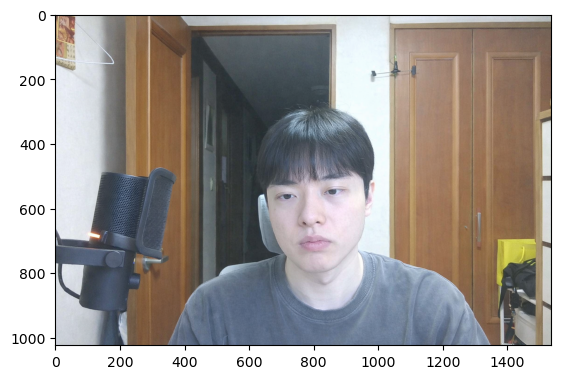

In [2]:
home_dir = os.getenv('HOME')
my_image_path = os.path.join(home_dir, 'work/AIFFEL_quest_eng/Computer_Vision/CV01/image.png')
img_bgr = cv2.imread(my_image_path)   
img_show = img_bgr.copy()      
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb)
plt.show()

### dlib HOG 얼굴 검출기를 생성하고 이미지에서 얼굴 영역을 찾습니다.
### 검출 결과(dlib_rects)는 이후 랜드마크 추출의 입력으로 사용됩니다.

In [3]:
detector_hog = dlib.get_frontal_face_detector()
dlib_rects = detector_hog(img_rgb, 1)

### 검출된 얼굴 박스를 시각화하여 얼굴 인식 결과를 확인합니다.
### 얼굴 위치가 정확한지 먼저 검증하는 단계입니다.

rectangles[[(633, 455) (954, 776)]]


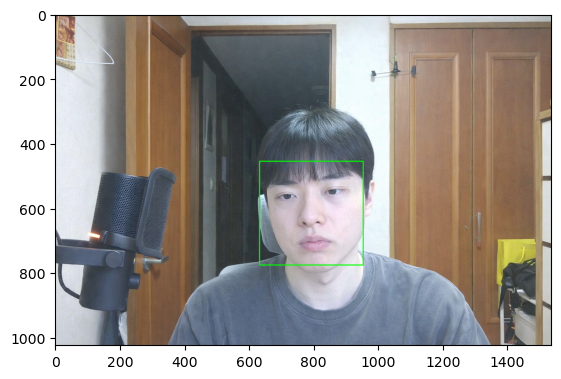

In [4]:
print(dlib_rects)

for dlib_rect in dlib_rects:
    l = dlib_rect.left()
    t = dlib_rect.top()
    r = dlib_rect.right()
    b = dlib_rect.bottom()

    cv2.rectangle(img_show, (l,t), (r,b), (0,255,0), 2, lineType=cv2.LINE_AA)

img_show_rgb =  cv2.cvtColor(img_show, cv2.COLOR_BGR2RGB)
plt.imshow(img_show_rgb)
plt.show()

### 68개 얼굴 랜드마크 예측 모델 파일을 로드합니다.
### 이 모델로 눈/코/입 등 기준점 좌표를 추출할 수 있습니다.

In [5]:
model_path = os.path.join(home_dir, 'work/AIFFEL_quest_eng/Computer_Vision/CV01/shape_predictor_68_face_landmarks.dat')
landmark_predictor = dlib.shape_predictor(model_path)

### 68개 얼굴 랜드마크 예측 모델 파일을 로드합니다.
### 이 모델로 눈/코/입 등 기준점 좌표를 추출할 수 있습니다.

In [6]:
list_landmarks = []

for dlib_rect in dlib_rects:
    points = landmark_predictor(img_rgb, dlib_rect)
    list_points = list(map(lambda p: (p.x, p.y), points.parts()))
    list_landmarks.append(list_points)

print(len(list_landmarks[0]))

68


### 추출한 랜드마크 점들을 이미지 위에 표시해 좌표 정확도를 확인합니다.
### 이후 수염 스티커를 배치할 기준점이 정상인지 점검합니다.

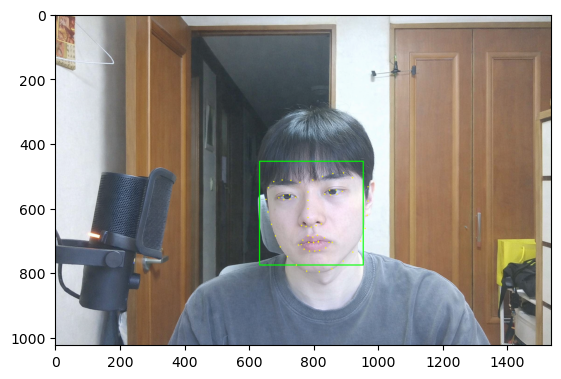

In [7]:
for landmark in list_landmarks:
    for point in landmark:
        cv2.circle(img_show, point, 2, (0, 255, 255), -1)

img_show_rgb = cv2.cvtColor(img_show, cv2.COLOR_BGR2RGB)
plt.imshow(img_show_rgb)
plt.show()

### 코 주변 랜드마크(33번)를 기준으로 수염 스티커 중심 좌표를 정합니다.
### 얼굴 크기에 비례해 스티커 너비/높이(w, h)를 계산합니다.

In [8]:
for dlib_rect, landmark in zip(dlib_rects, list_landmarks):
    x = landmark[33][0]
    y = landmark[33][1]
    w = dlib_rect.width()
    h = int(w * 0.6)

    print(f'(x,y) : ({x},{y})')
    print(f'(w,h) : ({w},{h})')

(x,y) : (793,659)
(w,h) : (322,193)


### 고양이 수염 스티커 이미지를 불러오고 계산한 크기(w, h)로 리사이즈합니다.
### 얼굴 크기에 맞는 비율로 합성하기 위한 준비 단계입니다.

In [9]:
sticker_path = os.path.join(home_dir, 'work/AIFFEL_quest_eng/Computer_Vision/CV01/cat-whiskers.png')
img_sticker = cv2.imread(sticker_path)

img_sticker = cv2.resize(img_sticker, (w, h))
print(img_sticker.shape)

(193, 322, 3)


### 스티커를 실제로 붙일 좌상단 좌표(refined_x, refined_y)를 계산합니다.
### 기준점(x, y)에서 스티커가 자연스럽게 위치하도록 오프셋을 적용합니다.

In [10]:
refined_x = x - w // 2
refined_y = y - int(h * 0.6)

print(f'(refined_x, refined_y) : ({refined_x}, {refined_y})')

(refined_x, refined_y) : (632, 544)


### 스티커 좌표가 이미지 바깥으로 나가는 경우를 예외 처리합니다.
### 음수 인덱스를 방지해 합성 중 오류가 나지 않도록 보정합니다.

In [11]:
if refined_x < 0:
    img_sticker = img_sticker[:, -refined_x:]
    refined_x = 0

if refined_y < 0:
    img_sticker = img_sticker[-refined_y:, :]
    refined_y = 0

print (f'(x,y) : ({refined_x},{refined_y})')

(x,y) : (632,544)


### 스티커를 붙일 영역을 잘라낸 뒤, 흰색 배경은 제외하고 합성합니다.
### np.where로 배경(거의 흰색)은 원본 유지, 수염 부분만 덮어씁니다.

In [12]:
sticker_area = img_show[
    refined_y:refined_y+img_sticker.shape[0],
    refined_x:refined_x+img_sticker.shape[1]
]

img_show[
    refined_y:refined_y+img_sticker.shape[0],
    refined_x:refined_x+img_sticker.shape[1]
] = np.where(
    np.all(img_sticker > 240, axis=2)[:, :, np.newaxis],
    sticker_area,
    img_sticker
).astype(np.uint8)

### 수염 스티커가 합성된 최종 결과 이미지를 출력합니다.
### 시각적으로 결과 품질을 확인하는 단계입니다.

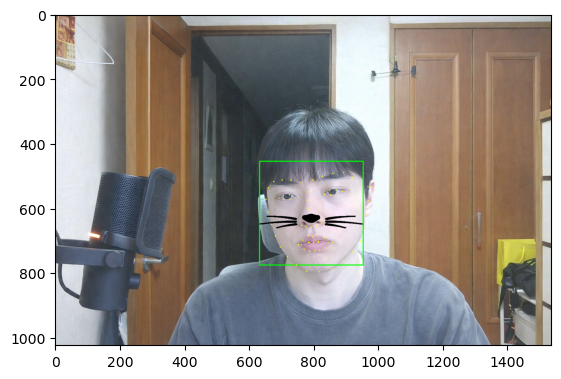

In [13]:
plt.imshow(cv2.cvtColor(img_show, cv2.COLOR_BGR2RGB))
plt.show()